In [ ]:
# PCA（Principal Component Analysis，主成分分析）是一种常用的降维技术，旨在通过线性变换将原始数据转换到一个新的坐标系中，使得数据在新坐标系中的方差最大化。PCA的主要步骤包括：
# 1. 数据中心化：将数据的每个特征减去其均值，使得数据的均值为0。
# 2. 计算协方差矩阵：计算中心化后的数据的协方差矩阵，描述特征之间的线性关系。
# 3. 特征值分解：对协方差矩阵进行特征值分解，得到特征值和对应的特征向量。特征值表示每个主成分的方差大小，特征向量表示主成分的方向。
# 4. 选择主成分：根据特征值的大小选择前k个主成分，构成新的特征空间。
# 5. 数据投影：将原始数据投影到选定的主成分上，得到降维后的数据。

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## 手动构建特征数据

In [13]:
# 定义数据
n = 1000
# 第1个主成分方向
component1 = np.random.normal(0, 1, n) # normal 生成符合正态分布的随机数，参数分别为均值、标准差和数量
# 第2个主成分方向
component2 = np.random.normal(0, 0.2, n)
# 第3个方向（噪声，方差较小）
noise = np.random.normal(0, 0.1, n)
# 构造3维特征
feature1 = component1 - component2
feature2 = component1 + component2
feature3 = component2 + noise
X = np.vstack((feature1, feature2, feature3)).T # vstack 将特征1、特征2和特征3垂直堆叠，T 转置
print(X.shape)

(1000, 3)


## PCA降维

In [14]:
# 定义PCA实例对象
pca = PCA(n_components=2) # n_components 设置要保留的主成分数量，这里设置为2，表示将原始的3维数据降到2维

In [15]:
# 应用PCA，将数据降维
X_pca = pca.fit_transform(X) # fit_transform 先拟合数据，然后进行变换（将原始数据降维）
print(X_pca.shape)

(1000, 2)


## 可视化

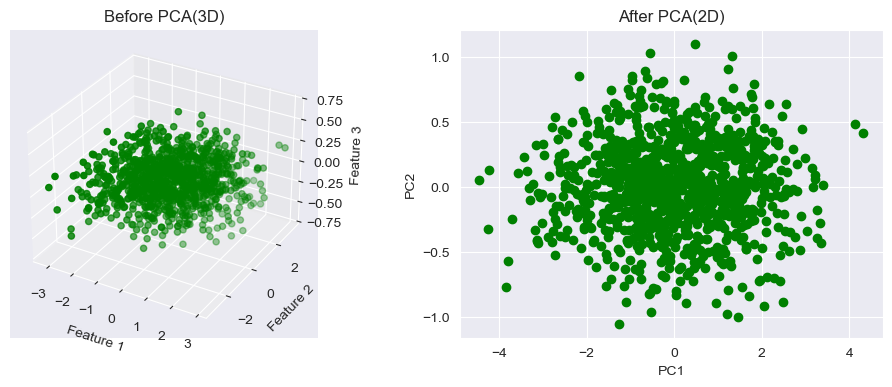

In [16]:
fig = plt.figure(figsize=(12, 4))
# 第一个子图，3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c="g") # scatter 绘制散点图，alpha 设置点的透明度、
ax1.set_title("Before PCA(3D)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.set_zlabel("Feature 3")

# 第二个子图，2D
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c="g") # scatter 绘制散点图，alpha 设置点的透明度
ax2.set_title("After PCA(2D)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.show()

